<a href="https://colab.research.google.com/github/komazawa-deep-learning/komazawa-deep-learning.github.io/blob/master/2026notebooks/2026ai_lect02.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 人工知能I 第2回：AI の背景と論点

## 📝 このノートブックについて

**位置づけ**: 自習用教材  
**目的**: 授業で学んだ理論を実際に体験する  
**所要時間**: 30-45分程度

### 本日の実習内容

1. チューリングテストの体験
2. ELIZAスタイルチャットボット
3. AIの歴史タイムライン可視化
4. Invited talkとの接続（振り返り）

**注意**: このノートブックは授業時間外に各自で実行してください。


---
## 1. チューリングテストとは

### 1.1 背景

**Alan Turing (1950)**  
*Computing Machinery and Intelligence*

**根本的な問い**:  
"Can machines think?"（機械は考えることができるか？）

**チューリングの提案**:  
この問いに直接答えるのではなく、**イミテーションゲーム**で判定する

### 1.2 イミテーションゲームのルール

1. 質問者（人間）
2. 回答者A（人間）
3. 回答者B（コンピュータ）

質問者はテキストでのやり取りのみで、AとBのどちらが人間かを当てる。
コンピュータが人間と区別できなければ「知能がある」と判定。

---
## 2. 環境準備

In [1]:
# 必要なライブラリのインポート
import random
import re
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 日本語フォントの設定
!pip install japanize-matplotlib --quiet
import japanize_matplotlib

print("環境準備完了")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 27.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
環境準備完了


---
## 3. 簡単なチャットボット（ルールベース）

### 3.1 最もシンプルなチャットボット

In [2]:
def simple_chatbot(user_input):
    """
    最もシンプルなルールベースチャットボット
    """
    # 入力を小文字に変換
    user_input = user_input.lower()

    # ルールベースの応答
    if "こんにちは" in user_input or "hello" in user_input:
        return "こんにちは！お元気ですか？"

    elif "名前" in user_input:
        return "私はシンプルなチャットボットです。"

    elif "天気" in user_input:
        return "私は天気の情報は持っていませんが、今日は良い日ですね。"

    elif "好き" in user_input:
        return "私はプログラミングが好きです！"

    elif "ありがとう" in user_input or "thank" in user_input:
        return "どういたしまして！"

    elif "さようなら" in user_input or "bye" in user_input:
        return "さようなら！また話しましょう。"

    else:
        return "それは興味深いですね。もう少し詳しく教えてください。"

# テスト
print("=== シンプルチャットボットのテスト ===")
test_inputs = [
    "こんにちは",
    "あなたの名前は？",
    "天気はどうですか？",
    "ありがとう"
]

for user_input in test_inputs:
    response = simple_chatbot(user_input)
    print(f"ユーザー: {user_input}")
    print(f"ボット: {response}")
    print()

=== シンプルチャットボットのテスト ===
ユーザー: こんにちは
ボット: こんにちは！お元気ですか？

ユーザー: あなたの名前は？
ボット: 私はシンプルなチャットボットです。

ユーザー: 天気はどうですか？
ボット: 私は天気の情報は持っていませんが、今日は良い日ですね。

ユーザー: ありがとう
ボット: どういたしまして！



### 3.2 インタラクティブに試してみる

In [3]:
# インタラクティブなチャット
print("=== チャットボットと会話してみよう ===")
print("（'終了'と入力すると終わります）\n")

while True:
    user_input = input("あなた: ")

    if user_input.lower() in ['終了', 'quit', 'exit']:
        print("ボット: さようなら！")
        break

    response = simple_chatbot(user_input)
    print(f"ボット: {response}\n")

=== チャットボットと会話してみよう ===
（'終了'と入力すると終わります）

あなた: ねむい
ボット: それは興味深いですね。もう少し詳しく教えてください。

あなた: 
ボット: それは興味深いですね。もう少し詳しく教えてください。

あなた: 終了
ボット: さようなら！


### 3.3 考察：このボットは「知能」を持っているか？

**チューリングテストの視点**
- 人間らしい応答ができているか？
- どのような質問で「ボット」だとバレるか？

**中国語の部屋の視点**
- ボットは「理解」しているか？
- それとも単なるルール適用か？

---
## 4. ELIZAスタイルのチャットボット

### 4.1 ELIZAとは

**ELIZA（1966）**
- Joseph Weizenbaum（MIT）が開発
- 最初期のチャットボット
- 心理療法士（ロジャース派）を模擬
- パターンマッチングと変換ルール

### 4.2 ELIZAスタイルの実装

In [11]:
class ELIZABot:
    """
    ELIZAスタイルのチャットボット（修正版）
    """

    def __init__(self):
        self.patterns = [
            (r'.*私は(.+)が好き.*',
             ['なぜ{0}が好きなのですか？',
              '{0}のどこが好きなのですか？',
              '{0}について詳しく教えてください。']),

            (r'.*私は(.+)が嫌い.*',
             ['なぜ{0}が嫌いなのですか？',
              '{0}の何が嫌いなのですか？']),

            (r'.*私は(.+)したい.*',
             ['なぜ{0}したいのですか？',
              '{0}したら、どうなると思いますか？']),

            (r'.*私は(.+)です',
             ['あなたが{0}であることについて、どう感じますか？',
              '{0}であることは大切ですか？']),

            (r'.*悲しい.*',
             ['悲しいのですね。それについて話してください。',
              'なぜ悲しいのですか？']),

            (r'.*嬉しい.*',
             ['嬉しいのですね！それは素晴らしいです。',
              'なぜ嬉しいのですか？']),

            (r'(.*)',
             ['それについてもう少し詳しく話してください。',
              'それはどういう意味ですか？',
              'それについてどう感じますか？',
              'もう少し詳しく教えてください。'])
        ]

    def respond(self, user_input):
        for pattern, responses in self.patterns:
            match = re.match(pattern, user_input)
            if match:
                response = random.choice(responses)
                groups = match.groups()
                if groups and groups[0]:
                    try:
                        return response.format(*groups)
                    except (IndexError, KeyError):
                        return response
                else:
                    return response
        return "それについてもう少し詳しく話してください。"

### 4.3 ELIZAと会話してみる

In [ ]:
# ELIZAとのインタラクティブな会話
print("=== ELIZA（心理療法士ボット）===")
print("あなたの気持ちを話してください。")
print("（'終了'と入力すると終わります）\n")

eliza = ELIZABot()

while True:
    user_input = input("あなた: ")

    if user_input.lower() in ['終了', 'quit', 'exit']:
        print("ELIZA: お話しできて良かったです。またお会いしましょう。")
        break

    response = eliza.respond(user_input)
    print(f"ELIZA: {response}\n")

=== ELIZA（心理療法士ボット）===
あなたの気持ちを話してください。
（'終了'と入力すると終わります）

あなた: 私は
ELIZA: それについてもう少し詳しく話してください。

あなた: 私は人工知能が嫌いです
ELIZA: なぜ人工知能が嫌いなのですか？

あなた: だって，
ELIZA: もう少し詳しく教えてください。

あなた: だるい
ELIZA: もう少し詳しく教えてください。

あなた: だるいんだってば
ELIZA: もう少し詳しく教えてください。



### 4.4 考察：ELIZAの「錯覚」

**Weizenbaumの発見**
- 多くの人がELIZAを「理解している」と感じた
- 単純なパターンマッチングなのに
- **ELIZA効果**: 人間は機械に意味を投影する

**中国語の部屋との関連**
- ELIZAは「理解」していない
- しかし人間には「理解している」ように見える
- 記号操作 vs 意味理解

---
## 5. AIの歴史タイムライン

### 5.1 主要な出来事のデータ

In [6]:
# AIの歴史データ
ai_history = [
    {'year': 1950, 'event': 'チューリングテスト提案', 'type': '理論'},
    {'year': 1956, 'event': 'ダートマス会議（AI誕生）', 'type': '会議'},
    {'year': 1966, 'event': 'ELIZA開発', 'type': '実装'},
    {'year': 1969, 'event': 'パーセプトロンの限界指摘', 'type': '冬の始まり'},
    {'year': 1980, 'event': '中国語の部屋（Searle）', 'type': '理論'},
    {'year': 1980, 'event': 'エキスパートシステムブーム', 'type': 'ブーム'},
    {'year': 1986, 'event': 'バックプロパゲーション再発見', 'type': '技術'},
    {'year': 1995, 'event': '第2次AIの冬', 'type': '冬'},
    {'year': 1997, 'event': 'Deep Blue（チェス世界王者に勝利）', 'type': '成果'},
    {'year': 2012, 'event': 'AlexNet（ImageNet優勝）', 'type': 'ブーム'},
    {'year': 2016, 'event': 'AlphaGo（囲碁世界王者に勝利）', 'type': '成果'},
    {'year': 2018, 'event': 'BERT（自然言語処理革命）', 'type': '技術'},
    {'year': 2020, 'event': 'GPT-3（大規模言語モデル）', 'type': '技術'},
    {'year': 2022, 'event': 'ChatGPT公開', 'type': '成果'},
    {'year': 2023, 'event': 'GPT-4、生成AI普及', 'type': '成果'}
]

df_history = pd.DataFrame(ai_history)
print("=== AIの歴史 ===")
print(df_history.to_string(index=False))

=== AIの歴史 ===
 year                 event  type
 1950           チューリングテスト提案    理論
 1956         ダートマス会議（AI誕生）    会議
 1966               ELIZA開発    実装
 1969          パーセプトロンの限界指摘 冬の始まり
 1980        中国語の部屋（Searle）    理論
 1980         エキスパートシステムブーム   ブーム
 1986        バックプロパゲーション再発見    技術
 1995               第2次AIの冬     冬
 1997 Deep Blue（チェス世界王者に勝利）    成果
 2012   AlexNet（ImageNet優勝）   ブーム
 2016    AlphaGo（囲碁世界王者に勝利）    成果
 2018        BERT（自然言語処理革命）    技術
 2020       GPT-3（大規模言語モデル）    技術
 2022             ChatGPT公開    成果
 2023          GPT-4、生成AI普及    成果


### 5.2 タイムラインの可視化

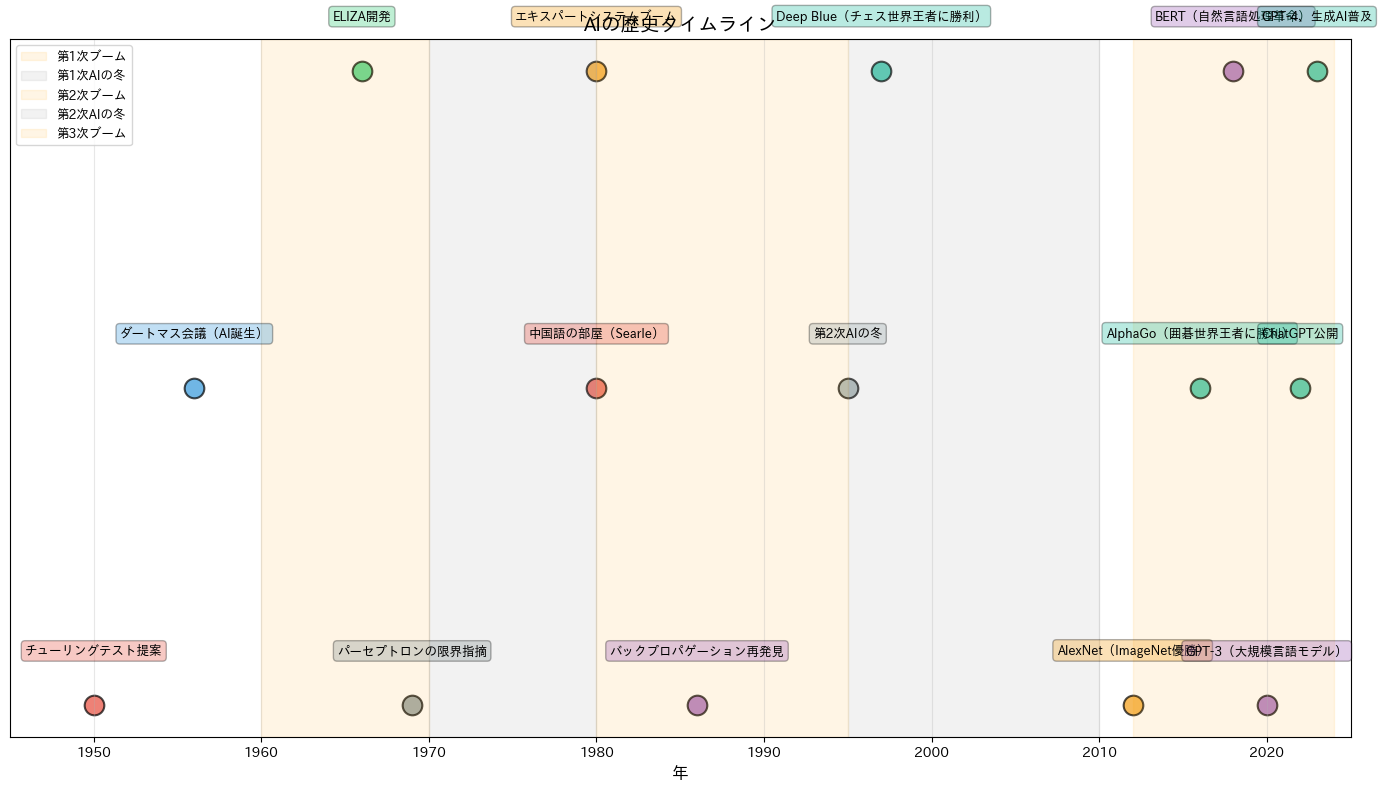

In [7]:
# タイムラインの可視化
fig, ax = plt.subplots(figsize=(14, 8))

# イベントタイプごとに色分け
colors = {
    '理論': '#e74c3c',
    '会議': '#3498db',
    '実装': '#2ecc71',
    '技術': '#9b59b6',
    'ブーム': '#f39c12',
    '冬': '#95a5a6',
    '冬の始まり': '#7f8c8d',
    '成果': '#1abc9c'
}

# 各イベントをプロット
for idx, row in df_history.iterrows():
    y_pos = idx % 3  # 3段に配置
    ax.scatter(row['year'], y_pos, s=200,
              color=colors.get(row['type'], '#34495e'),
              alpha=0.7, edgecolors='black', linewidth=1.5)

    # イベント名を表示
    ax.text(row['year'], y_pos + 0.15, row['event'],
           fontsize=9, ha='center', va='bottom',
           bbox=dict(boxstyle='round,pad=0.3',
                    facecolor=colors.get(row['type'], '#34495e'),
                    alpha=0.3))

# ブームと冬の期間を示す背景
ax.axvspan(1960, 1970, alpha=0.1, color='orange', label='第1次ブーム')
ax.axvspan(1970, 1980, alpha=0.1, color='gray', label='第1次AIの冬')
ax.axvspan(1980, 1995, alpha=0.1, color='orange', label='第2次ブーム')
ax.axvspan(1995, 2010, alpha=0.1, color='gray', label='第2次AIの冬')
ax.axvspan(2012, 2024, alpha=0.1, color='orange', label='第3次ブーム')

ax.set_xlabel('年', fontsize=12)
ax.set_yticks([])
ax.set_title('AIの歴史タイムライン', fontsize=14, fontweight='bold')
ax.set_xlim(1945, 2025)
ax.grid(True, alpha=0.3, axis='x')
ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

### 5.3 ブームと冬のパターン

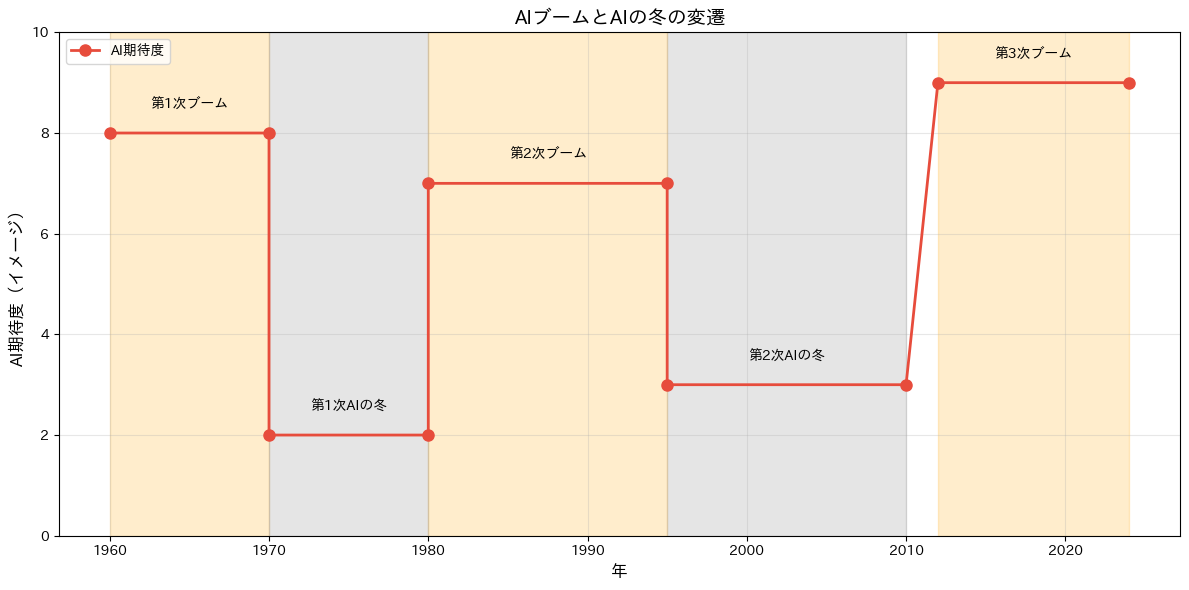


=== 考察ポイント ===
- なぜブームと冬が繰り返されるのか？
- 第3次ブームは持続するか？
- 過度な期待と現実のギャップ


In [8]:
# ブームと冬のパターンを可視化
periods = [
    {'period': '第1次ブーム', 'start': 1960, 'end': 1970, 'hype': 8},
    {'period': '第1次AIの冬', 'start': 1970, 'end': 1980, 'hype': 2},
    {'period': '第2次ブーム', 'start': 1980, 'end': 1995, 'hype': 7},
    {'period': '第2次AIの冬', 'start': 1995, 'end': 2010, 'hype': 3},
    {'period': '第3次ブーム', 'start': 2012, 'end': 2024, 'hype': 9}
]

# 折れ線グラフの作成
fig, ax = plt.subplots(figsize=(12, 6))

years = []
hype_levels = []

for period in periods:
    years.extend([period['start'], period['end']])
    hype_levels.extend([period['hype'], period['hype']])

ax.plot(years, hype_levels, marker='o', linewidth=2, markersize=8,
       color='#e74c3c', label='AI期待度')

# 期間の色分け
for period in periods:
    color = 'orange' if 'ブーム' in period['period'] else 'gray'
    ax.axvspan(period['start'], period['end'], alpha=0.2, color=color)

    # ラベル
    mid_year = (period['start'] + period['end']) / 2
    ax.text(mid_year, period['hype'] + 0.5, period['period'],
           ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('年', fontsize=12)
ax.set_ylabel('AI期待度（イメージ）', fontsize=12)
ax.set_title('AIブームとAIの冬の変遷', fontsize=14, fontweight='bold')
ax.set_ylim(0, 10)
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

print("\n=== 考察ポイント ===")
print("- なぜブームと冬が繰り返されるのか？")
print("- 第3次ブームは持続するか？")
print("- 過度な期待と現実のギャップ")

---
## 6. Invited Talkとの接続

### 6.1 振り返りと統合

**理論と実践を結びつける**

本日のinvited talkで学んだ内容を、授業の理論と結びつけて考えてみましょう。

### 6.2 振り返り課題（準備学習）

以下の問いについて考え、記録してください。

#### 問1: Invited talkと理論の接続

本日のinvited talkで印象に残った内容を1つ挙げ、それが以下のどの理論と関連するか説明してください。

- **チューリングテスト**: AIの「知能」の定義
- **中国語の部屋**: 実装と理解の違い
- **AIの歴史**: ブームと冬、技術の進化

#### 問2: 実務のAIについて

Invited talkで紹介されたAI技術は、「弱いAI」と「強いAI」のどちらに分類されますか？その理由も含めて説明してください。

#### 問3: 心理学との接点

Invited talkの内容から、心理学の知識がどのように活かされているか（または活かせそうか）を考えてください。

### 6.3 解答欄（ここに記入してください）

**問1: Invited talkと理論の接続**（150字程度）




**問2: 弱いAI vs 強いAI**（100字程度）




**問3: 心理学との接点**（100字程度）




---
## 7. 発展課題（任意）

### 課題1: チャットボットの改良

ELIZAボットにパターンを追加して、より人間らしい会話ができるようにしてみましょう。

### 課題2: チューリングテストの実験

友人とチューリングテストを試してみましょう。
1. 一人がチャットボット役
2. もう一人が質問者
3. どのような質問でバレるか観察

### 課題3: AIの歴史調査

タイムラインに含まれていない重要な出来事を調べて追加してみましょう。

In [ ]:
# 発展課題のための作業スペース



---
## 8. まとめ

### 8.1 本日学んだこと

**理論**
1. **チューリングテスト**: 行動による知能の判定
2. **中国語の部屋**: 記号操作 ≠ 理解
3. **AIの歴史**: ブームと冬の繰り返し
4. **認知科学**: 心理学とAIの融合

**実践**
1. ルールベースチャットボットの実装
2. ELIZAスタイルのパターンマッチング
3. AIの歴史の可視化
4. Invited talkとの接続

### 8.2 次回予告

**第3回: 回帰分析の基礎**
- 線形回帰
- 最小二乗法
- モデルの評価

---
## 参考文献

1. Turing, A. M. (1950). Computing machinery and intelligence. *Mind, 59*(236), 433-460.

2. Searle, J. R. (1980). Minds, brains, and programs. *Behavioral and Brain Sciences, 3*(3), 417-424.

3. Weizenbaum, J. (1966). ELIZA—a computer program for the study of natural language communication between man and machine. *Communications of the ACM, 9*(1), 36-45.

4. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.). Pearson.

---

## 謝辞

本日の招待講演にご協力いただいた 東京技術計算コンサルタント様に感謝申し上げます。

---

*人工知能I 第2回実習ノートブック*